# SNA PROJECT: ANALYSIS OF THE MARVEL UNIVERSE SOCIAL NETWORK

Name: Jakub Stachecki

Email: jstachecki@student.agh.edu.pl

Date: 13.03.2026

---

## NETWORK DESCRIPTION

Description:

This project analyzes the social structure of the Marvel Universe character network. It models a "collaboration network" where interactions between fictional characters mimic real-world social dynamics.

Nodes and Edges Representation:
* Nodes: Characters from the Marvel Universe (e.g. Spider-Man, Iron Man).
* Edges: A link connects two nodes if the characters have appeared together in the same comic book issue.
* Network Type: The network is undirected (co-appearance is mutual) and weighted (the weight represents the amount of co-occurrences).



## 1.1 Data downloading and cleaning

Data Source:
[The Marvel Universe Social Network](https://www.kaggle.com/datasets/csanhueza/the-marvel-universe-social-network).

Dataset used:
* hero-network.csv: Contains pairs of heroes that appear in the same comic.

Data Fields Explanation:
* hero1, hero2: String identifiers for the characters.
* weight: The total number of times  hero1 and hero2 appeared together.

To get the data ready for analysis, I need to load the raw edge list, drop any self-loops, and aggregate repeated co-occurrences into a single weighted edge for each character pair.

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_edges = pd.read_csv('hero-network.csv')

print("\n--- Raw data sample ---")
display(df_edges.head(5))

#Remove self-loops (Spider-Man connected to Spider-Man) - without this line, there are 12 more total edges in graph - which are artifacts present in raw Kaggle dataset
df_edges = df_edges[df_edges['hero1'] != df_edges['hero2']]

# Remove whitespaces from hero names and sort alphabetically
df_edges['hero1'] = df_edges['hero1'].str.strip()
df_edges['hero2'] = df_edges['hero2'].str.strip()
df_edges[['hero1', 'hero2']] = np.sort(df_edges[['hero1', 'hero2']], axis=1)

# Group by pairs to calculate weights
df_weighted = df_edges.groupby(['hero1', 'hero2']).size().reset_index(name='weight')

print("\n--- Processed weighted data sample ---")
df_weighted.sort_values(by='weight', ascending=False, inplace=True)
display(df_weighted.head(5))

G_raw = nx.from_pandas_edgelist(df_weighted, source='hero1', target='hero2', edge_attr='weight')
print(f"\nGraph created with {G_raw.number_of_nodes()} nodes and {G_raw.number_of_edges()} edges.")


--- Raw data sample ---


,hero1,hero2
0,"LITTLE, ABNER",PRINCESS ZANDA
1,"LITTLE, ABNER",BLACK PANTHER/T'CHAL
2,BLACK PANTHER/T'CHAL,PRINCESS ZANDA
3,"LITTLE, ABNER",PRINCESS ZANDA
4,"LITTLE, ABNER",BLACK PANTHER/T'CHAL



--- Processed weighted data sample ---


,hero1,hero2,weight
134272,MISS AMERICA/MADELIN,PATRIOT/JEFF MACE,1894
103426,HUMAN TORCH/JOHNNY S,THING/BENJAMIN J. GR,744
103014,HUMAN TORCH/JOHNNY S,MR. FANTASTIC/REED R,713
137327,MR. FANTASTIC/REED R,THING/BENJAMIN J. GR,708
106575,INVISIBLE WOMAN/SUE,MR. FANTASTIC/REED R,701



Graph created with 6421 nodes and 167100 edges.


## 1.2 Network characterization

I characterize the main parameters of the network, identify and then calculate metrics of the giant component.

In [7]:
nodes_raw = G_raw.number_of_nodes()
edges_raw = G_raw.number_of_edges()
components = list(nx.connected_components(G_raw))

print(f"Network before giant component identification:")
print(f"- Nodes: {nodes_raw}")
print(f"- Edges: {edges_raw}")
print(f"- Number of connected components: {len(components)}")

# Extract giant component
gc_nodes = max(components, key=len)
G = G_raw.subgraph(gc_nodes).copy()

nodes_gc = G.number_of_nodes()
edges_gc = G.number_of_edges()

print(f"\nGiant component:")
print(f"- Nodes: {nodes_gc} ({(nodes_gc/nodes_raw)*100:.2f}% of original)")
print(f"- Edges: {edges_gc} ({(edges_gc/edges_raw)*100:.2f}% of original)")

Network before giant component identification:
- Nodes: 6421
- Edges: 167100
- Number of connected components: 4

Giant component:
- Nodes: 6403 (99.72% of original)
- Edges: 167044 (99.97% of original)


Almost the entire Marvel Universe (over 99% of nodes) is connected within a single giant component. This portrays the publishing strategy of Marvel Comics, which is that the crossovers are frequent and almost every character is connected to the main narrative.

I will use this giant component for all further calculations.

Average degree: 52.18
Average clustering coefficient: 0.7744
Average shortest path length: 2.6384
Network diameter: 5


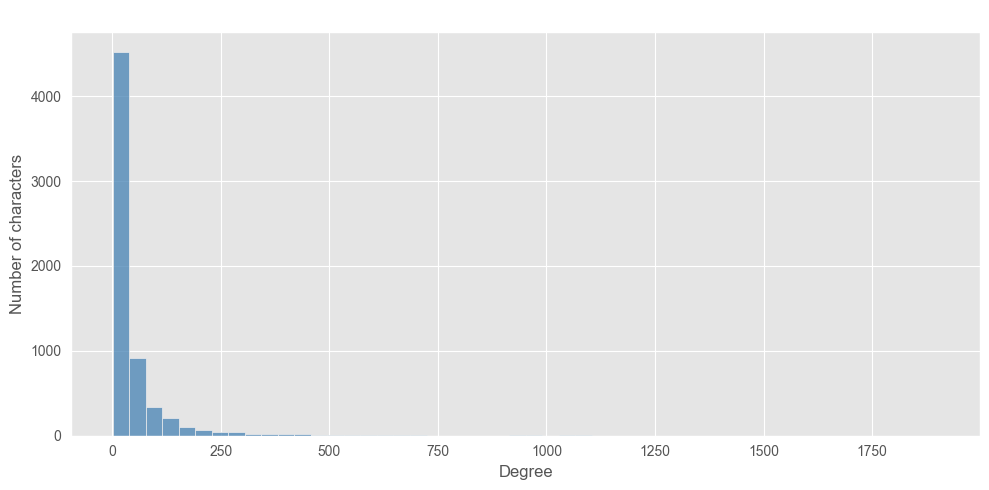

In [8]:
plt.style.use('ggplot')

degrees = [d for n, d in G.degree()]
avg_degree = sum(degrees) / nodes_gc
clustering_coeff = nx.average_clustering(G)
avg_path_length = nx.average_shortest_path_length(G)
diameter = nx.diameter(G)

print(f"Average degree: {avg_degree:.2f}")
print(f"Average clustering coefficient: {clustering_coeff:.4f}")
print(f"Average shortest path length: {avg_path_length:.4f}")
print(f"Network diameter: {diameter}")

# Plot degree distribution
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(degrees, bins=50, kde=False, color='steelblue', ax=ax)

ax.set_title('Degree Distribution', fontsize=14)
ax.set_xlabel('Degree', fontsize=12)
ax.set_ylabel('Number of characters', fontsize=12)

plt.tight_layout()
plt.show()

The average degree of 52 is quite high, meaning that characters interact with many other, and high clustering coefficient of 0.77 shows that they form teams (like Avengers or X-Men). The average shortest path length of 2.64 shows that the Marvel Universe is a "Small World", which means that any two characters are linked by a very small amount of mutual acquaintances. The degree distribution plot is heavily right-skewed, this means that a majority of characters have very few connections, while the most popular few have hundreds.

## 1.3 Centrality measures

I calculate three centrality measures to identify the most important characters in the network. The graph is undirected, so I use Degree, Closeness, and Betweenness centralities.

In [9]:
# k=200 is used for betweenness to approximate and save computational time
deg_cent = nx.degree_centrality(G)
clo_cent = nx.closeness_centrality(G)
bet_cent = nx.betweenness_centrality(G, k=200, weight='weight', normalized=True, seed=20)

df_centrality = pd.DataFrame({
    'Character': list(G.nodes()),
    'Degree': list(deg_cent.values()),
    'Closeness': list(clo_cent.values()),
    'Betweenness': list(bet_cent.values()),
})

metrics = ['Degree', 'Closeness', 'Betweenness']
for metric in metrics:
    print(f"\n--- Top 5 by {metric} centrality ---")
    display(df_centrality.sort_values(by=metric, ascending=False).head(5)[['Character', metric]])


--- Top 5 by Degree centrality ---


,Character,Degree
9,CAPTAIN AMERICA,0.297251
6,SPIDER-MAN/PETER PAR,0.271321
10,IRON MAN/TONY STARK,0.237582
3,THING/BENJAMIN J. GR,0.221181
4,MR. FANTASTIC/REED R,0.215089



--- Top 5 by Closeness centrality ---


,Character,Closeness
9,CAPTAIN AMERICA,0.585245
6,SPIDER-MAN/PETER PAR,0.575771
10,IRON MAN/TONY STARK,0.563011
3,THING/BENJAMIN J. GR,0.559420
4,MR. FANTASTIC/REED R,0.557568



--- Top 5 by Betweenness centrality ---


,Character,Betweenness
6,SPIDER-MAN/PETER PAR,0.041445
9,CAPTAIN AMERICA,0.033265
36,HULK/DR. ROBERT BRUC,0.031280
25,HAWK,0.029747
64,"FURY, COL. NICHOLAS",0.024350


Degree centrality identifies characters with the highest number of collaborators. Captain America, Spider-Man and Iron Man are the faces of the Marvel Comics so they are inserted into many comic series to boost sales. Closeness centrality measures how fast a character can reach anyone else in the network, and the characters with the biggest closeness are the same as those with the largest degree. Characters with high betweenness act as bridges between different teams or storylines (Wolverine, both an X-men and Avengers member) and ensure that the whole universe is connected.

## 1.4 Comparison with network models

To see if the Marvel Universe network is random or if it follows specific patterns, I compare its metrics with three theoretical models: Erdos-Renyi (Random), Watts-Strogatz (Small-World), and Barabasi-Albert (Scale-Free).

,Network,Clustering Coeff
0,Empirical (Marvel),0.7744
1,Random,0.0082
2,Small-World,0.5378
3,Scale-Free,0.0307


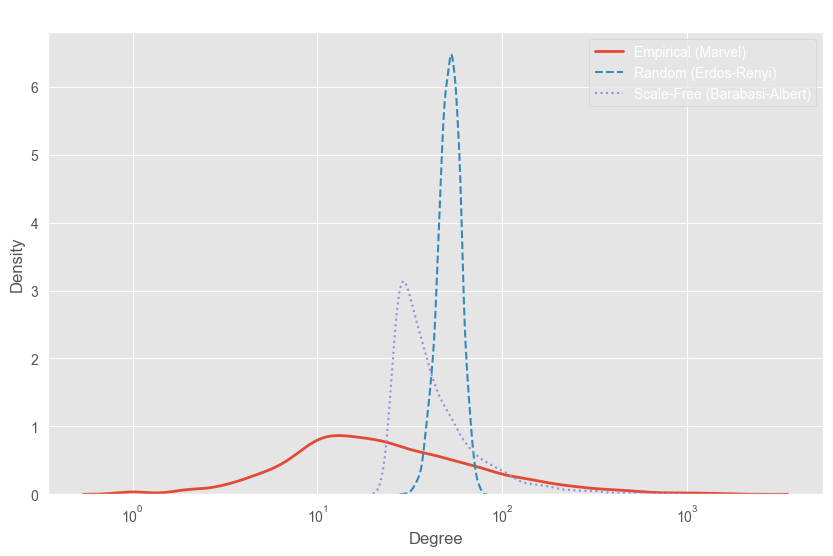

In [11]:
n = G.number_of_nodes()
m = G.number_of_edges()

#Random Graph (Erdos-Renyi)
p_er = (2 * m) / (n * (n - 1))
G_er = nx.erdos_renyi_graph(n, p_er, seed=20)

#Small-World Graph (Watts-Strogatz)
k_ws = int(avg_degree)
p_ws = 0.1
G_ws = nx.watts_strogatz_graph(n, k_ws, p_ws, seed=20)

#Scale-Free Graph (Barabasi-Albert)
m_ba = int(avg_degree / 2)
G_ba = nx.barabasi_albert_graph(n, m_ba, seed=20)

models_data = []
models = {'Empirical (Marvel)': G, 'Random': G_er, 'Small-World': G_ws, 'Scale-Free': G_ba}

for name, graph in models.items():
    c = nx.average_clustering(graph)
    models_data.append({'Network': name, 'Clustering Coeff': round(c, 4)})

df_models = pd.DataFrame(models_data)
display(df_models)

#Plot degree distributions
deg_emp = [d for n, d in G.degree()]
deg_er = [d for n, d in G_er.degree()]
deg_ba = [d for n, d in G_ba.degree()]

plt.figure(figsize=(10, 6))
sns.kdeplot(deg_emp, log_scale=True, label='Empirical (Marvel)', linewidth=2)
sns.kdeplot(deg_er, log_scale=True, label='Random (Erdos-Renyi)', linestyle='--')
sns.kdeplot(deg_ba, log_scale=True, label='Scale-Free (Barabasi-Albert)', linestyle=':')

plt.title('Degree Distribution Comparison', fontsize=15)
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

The table shows that the Marvel clustering coefficient is much higher than the random model. This proves that character interactions are not random, they are organized into specific groups. The density plot shows the random graph has a Poisson-like distribution, which is completely different from the Marvel Universe graph. The Marvel network shares the high clustering of the Small-World. This structure works well with comic universe because it allows authors to kepp localized stories, street level stories while still being able to integrate them into big crossovers. The degree distribution plot demonstrates that the Marvel network aligns closely with the heavy tail of the Scale-Free model. This is an example of preferential attachment: as new characters are made, they are more likely to be introduced alongside already famous heroes rather than unknown characters. This is a deliberate publishing strategy to boost the popularity of new characters.